In [16]:
#Will keep everything same as the original code , and will only add batch normalization to the code

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision.transforms import v2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True),
    v2.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root = "./data", train = True, download = True, transform = transform )
test_dataset = torchvision.datasets.CIFAR10(root = "./data", train = False, download = True, transform = transform)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True, pin_memory = torch.cuda.is_available())
test_loader = DataLoader(test_dataset, shuffle = False , batch_size = 64, pin_memory = torch.cuda.is_available())

classes = ('plane', 'car', 'bird', 'cat','deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [17]:
from torch.nn.modules.linear import Linear
from torch.nn.modules.flatten import Flatten
class Convolution(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Conv2d(3,6,3,1,1),
        nn.BatchNorm2d(6),
        nn.ReLU(),

        nn.Conv2d(6,12,3,1,1),
        nn.BatchNorm2d(12),
        nn.ReLU(),

        nn.MaxPool2d(2,2),

        nn.Conv2d(12,24,3,1,1),
        nn.BatchNorm2d(24),
        nn.ReLU(),

        nn.Conv2d(24,48,3,1,1),
        nn.BatchNorm2d(48),
        nn.ReLU(),

        nn.MaxPool2d(2,2),

        nn.Flatten(),

        nn.Linear(48*8*8, 600),
        nn.ReLU(),

        nn.Linear(600,120),
        nn.ReLU(),

        nn.Linear(120,24),
        nn.ReLU(),

        nn.Linear(24,10)
    )

  def forward(self,X):
    return self.model(X)


model = Convolution()
model = model.to(device)

print(model)

Convolution(
  (model): Sequential(
    (0): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Flatten(start_dim=1, end_dim=-1)
    (15): Linear(in_features=3072

In [18]:
lr = 0.001
epochs = 5
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = lr)

Epoch : [1 / 5] : 1.3823024925
Epoch : [2 / 5] : 0.9390383684
Epoch : [3 / 5] : 0.7723375275
Epoch : [4 / 5] : 0.6508180161
Epoch : [5 / 5] : 0.5540237387


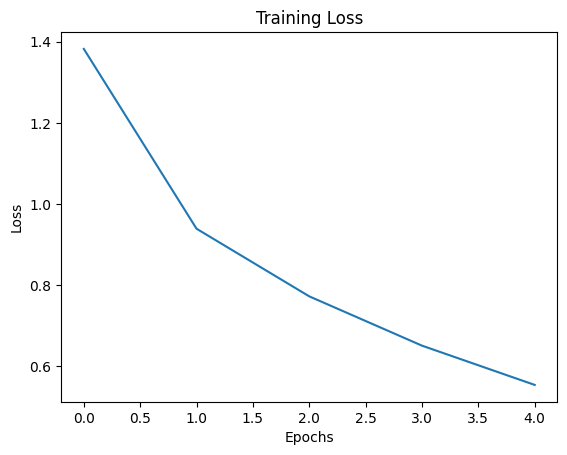

In [19]:
train_losses = []
for epoch in range(epochs):
  model.train()
  total_epoch_loss = 0;
  for batch_X, batch_y in train_loader:
    batch_X = batch_X.to(device)
    batch_y = batch_y.to(device)

    y_pred = model(batch_X)
    loss = loss_fn(y_pred, batch_y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss +=loss.item()
  average_epoch_loss = total_epoch_loss/len(train_loader)
  train_losses.append(average_epoch_loss)
  print(f"Epoch : [{epoch + 1 } / {epochs}] : {average_epoch_loss:.10f}")
plt.plot([t1 for t1 in train_losses])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()


In [20]:
correct = 0
total_labels = len(test_dataset)
model.eval()

with torch.no_grad():
  for batch_X, batch_y in test_loader:
    batch_correct_preds = 0
    batch_X = batch_X.to(device)
    batch_y  = batch_y.to(device)
    y_pred = model(batch_X)
    predicted_labels = torch.argmax(y_pred, dim =1)
    batch_correct_preds += (predicted_labels == batch_y).sum().item()
    correct += batch_correct_preds

print(correct)
acc = correct/ total_labels
print(f"The accuracy of the currrent model is : {acc*100:.10f}")

7457
The accuracy of the currrent model is : 74.5700000000
